# CatBoost + CNN Residual Learning Pipeline

This notebook implements the workflow from `compute_instruction.md` using the existing `processed_data/train.csv`, `processed_data/validation.csv`, and `processed_data/test.csv` files. 

## 1. Imports + Config

If the notebook kernel is missing packages, run:

```python
%pip install --upgrade --no-cache-dir pandas numpy catboost torch ipython
```

If you need a CUDA-enabled Torch build, use the install command from https://pytorch.org/get-started/locally/.

In [41]:
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import torch
from catboost import CatBoostError, CatBoostRegressor, Pool
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

DATA_DIR = Path("processed_data")
TARGET_COLUMN = "monthly_gross_return"
ID_COLUMN = "co_code"
DATE_COLUMN = "Month"
SOURCE_SPLIT_COLUMN = "source_split"

CAT_COLUMNS = [
    "Size_Label",
    "BM_Label",
    "OpProf_Label",
    "Inv_Label",
    "Mom_Label",
]
LAG_STEPS = (1, 3, 6)
ROLLING_WINDOWS = (3, 6)
SEQ_LEN = 6
CNN_TRAIN_FRACTION = 0.8
BATCH_SIZE = 1024
CNN_EPOCHS = 30
CNN_LR = 1e-3
WEIGHT_DECAY = 1e-4
TOP_K = 20
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#DEVICE = torch.device("cuda")
PIN_MEMORY = DEVICE.type == "cuda"

CB_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1500,
    "depth": 10,
    "learning_rate": 0.05,
    "l2_leaf_reg": 3.0,
    "random_seed": SEED,
    "verbose": 100,
    "task_type": "GPU",
}

print(f"Using device: {DEVICE}")


Using device: cpu


## 2. Data Load

The files are concatenated only for feature generation and then sliced back to the original split boundaries.


In [42]:
def read_split(path: Path, split_name: str) -> pd.DataFrame:
    frame = pd.read_csv(path, low_memory=False)
    frame[SOURCE_SPLIT_COLUMN] = split_name
    return frame


def drop_previous_engineering(df: pd.DataFrame) -> pd.DataFrame:
    explicit_drop = {
        "split_group",
        "month_index",
        "ret_lag_1",
        "ret_lag_3",
        "ret_lag_6",
        "ret_rolling_mean_3m",
        "ret_rolling_std_3m",
        "ret_rolling_mean_6m",
        "ret_rolling_std_6m",
        "ret_rolling_count_3m",
        "lag_ret",
        "log_ret",
        "log_ret_lag_1",
        "log_ret_lag_3",
        "log_ret_lag_6",
    }
    dynamic_drop = [
        column
        for column in df.columns
        if column in explicit_drop
        or column.startswith("is_missing_")
        or column.startswith("lag_ret_")
        or column.startswith("rolling_mean_")
        or column.startswith("rolling_std_")
    ]
    return df.drop(columns=dynamic_drop, errors="ignore")


def coerce_panel_types(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
    df[ID_COLUMN] = pd.to_numeric(df[ID_COLUMN], errors="coerce").astype("Int64")
    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

    for column in CAT_COLUMNS:
        if column in df.columns:
            df[column] = (
                df[column]
                .astype("string")
                .str.strip()
                .replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA})
                .fillna("__MISSING__")
            )

    excluded = {ID_COLUMN, TARGET_COLUMN, DATE_COLUMN, SOURCE_SPLIT_COLUMN, *CAT_COLUMNS}
    for column in df.columns:
        if column not in excluded:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    return df.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)


def collapse_duplicate_company_months(df: pd.DataFrame):
    duplicate_key_mask = df.duplicated([ID_COLUMN, DATE_COLUMN], keep=False)
    duplicate_key_count = int(
        df.loc[duplicate_key_mask, [ID_COLUMN, DATE_COLUMN]].drop_duplicates().shape[0]
    )
    duplicate_rows_removed = int(df.duplicated([ID_COLUMN, DATE_COLUMN], keep="last").sum())

    if duplicate_rows_removed:
        print(
            f"Collapsing {duplicate_rows_removed} duplicate rows across {duplicate_key_count} "
            f"({ID_COLUMN}, {DATE_COLUMN}) keys by keeping the last occurrence per key."
        )

    deduped = df.drop_duplicates([ID_COLUMN, DATE_COLUMN], keep="last")
    deduped = deduped.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)
    return deduped, duplicate_key_count, duplicate_rows_removed


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    grouped = df.groupby(ID_COLUMN, sort=False)
    target_history = grouped[TARGET_COLUMN]
    past_return = target_history.shift(1)

    for lag in LAG_STEPS:
        df[f"lag_ret_{lag}"] = target_history.shift(lag)

    for window in ROLLING_WINDOWS:
        rolling = past_return.groupby(df[ID_COLUMN]).rolling(window=window, min_periods=1)
        df[f"rolling_mean_{window}"] = rolling.mean().reset_index(level=0, drop=True)
        df[f"rolling_std_{window}"] = rolling.std().reset_index(level=0, drop=True)

    if "log_ret" in df.columns:
        for lag in LAG_STEPS:
            df[f"log_ret_lag_{lag}"] = grouped["log_ret"].shift(lag)

    df["month_index"] = df[DATE_COLUMN].dt.year * 12 + df[DATE_COLUMN].dt.month
    return df


def add_missing_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for column in list(df.columns):
        if column in {ID_COLUMN, DATE_COLUMN, SOURCE_SPLIT_COLUMN}:
            continue
        indicator = f"is_missing_{column}"
        if indicator not in df.columns:
            df[indicator] = df[column].isna().astype("int8")
    return df


train_raw = read_split(DATA_DIR / "train.csv", "train")
validation_raw = read_split(DATA_DIR / "validation.csv", "validation")
test_raw = read_split(DATA_DIR / "test.csv", "test")

panel = pd.concat([train_raw, validation_raw, test_raw], ignore_index=True, sort=False)
panel = drop_previous_engineering(panel)
panel = coerce_panel_types(panel)
panel, duplicate_key_count, duplicate_rows_removed = collapse_duplicate_company_months(panel)
panel = engineer_features(panel)
panel = add_missing_indicators(panel)

split_frames = {
    split_name: panel.loc[panel[SOURCE_SPLIT_COLUMN] == split_name].copy().reset_index(drop=True)
    for split_name in ("train", "validation", "test")
}

summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(frame),
            "start_month": frame[DATE_COLUMN].min(),
            "end_month": frame[DATE_COLUMN].max(),
            "companies": frame[ID_COLUMN].nunique(),
        }
        for split_name, frame in split_frames.items()
    ]
)

display(summary)
display(split_frames["train"].head())


Collapsing 548 duplicate rows across 548 (co_code, Month) keys by keeping the last occurrence per key.


,split,rows,start_month,end_month,companies
0,train,400073,2001-05-01,2019-09-01,3976
1,validation,114245,2019-10-01,2023-09-01,3331
2,test,57561,2023-10-01,2025-03-01,3565


,co_code,Month,monthly_gross_return,mktcap,price,equity_bv_on_stkdate,fy_book_value,lag_mv,BM_sep,Size_Label,...,is_missing_Momentum,is_missing_Mom_Label,is_missing_lag_ret_1,is_missing_lag_ret_3,is_missing_lag_ret_6,is_missing_rolling_mean_3,is_missing_rolling_std_3,is_missing_rolling_mean_6,is_missing_rolling_std_6,is_missing_month_index
0,1,2016-09-01,0.994596,110.8762,27.60,403.6,394.8,110.4745,3.422109,S,...,0,0,1,1,1,1,1,1,1,0
1,1,2016-10-01,1.106926,122.5262,30.50,403.6,394.8,110.8762,3.640096,S,...,0,0,0,1,1,0,1,0,1,0
2,1,2016-11-01,0.801345,99.8288,24.85,403.6,394.8,122.5262,3.640096,S,...,0,0,0,1,1,0,0,0,0,0
3,1,2016-12-01,1.145383,114.4917,28.50,403.6,394.8,99.8288,3.640096,S,...,0,0,0,0,1,0,0,0,0,0
4,1,2017-01-01,1.003334,112.4831,28.00,406.2,394.8,114.4917,3.640096,S,...,0,0,0,0,1,0,0,0,0,0


## 3. Feature Construction + Split Verification

The assertions below make the split boundaries explicit and guard against time leakage.


In [43]:
duplicate_keys_remaining = int(panel.duplicated([ID_COLUMN, DATE_COLUMN]).sum())
if duplicate_keys_remaining > 0:
    print(
        f"Detected {duplicate_keys_remaining} duplicate (company, month) rows still present in `panel`. "
        "Re-collapsing duplicates and rebuilding split frames."
    )
    panel, duplicate_key_count, duplicate_rows_removed = collapse_duplicate_company_months(panel)
    split_frames = {
        split_name: panel.loc[panel[SOURCE_SPLIT_COLUMN] == split_name].copy().reset_index(drop=True)
        for split_name in ("train", "validation", "test")
    }
    duplicate_keys_remaining = int(panel.duplicated([ID_COLUMN, DATE_COLUMN]).sum())

train_end = split_frames["train"][DATE_COLUMN].max()
validation_start = split_frames["validation"][DATE_COLUMN].min()
validation_end = split_frames["validation"][DATE_COLUMN].max()
test_start = split_frames["test"][DATE_COLUMN].min()

company_split_counts = panel.groupby(ID_COLUMN)[SOURCE_SPLIT_COLUMN].nunique(dropna=False)
multi_split_companies = int((company_split_counts > 1).sum())
time_split_detected = multi_split_companies > 0

if time_split_detected:
    assert train_end < validation_start, "Train and validation periods overlap."
    assert validation_end < test_start, "Validation and test periods overlap."
    print("Detected time-based split (companies appear in multiple splits).")
else:
    if train_end >= validation_start or validation_end >= test_start:
        print("Note: date ranges overlap because splits are by company, not time.")
    assert multi_split_companies == 0, "Company appears in multiple splits."

assert duplicate_keys_remaining == 0, f"Found {duplicate_keys_remaining} duplicate (company, month) rows after collapse."

print(f"Train end month: {train_end:%Y-%m-%d}")
print(f"Validation window: {validation_start:%Y-%m-%d} -> {validation_end:%Y-%m-%d}")
print(f"Test start month: {test_start:%Y-%m-%d}")
print(f"Companies with multiple splits: {multi_split_companies}")
print(f"Duplicate company-month keys collapsed: {duplicate_key_count}")
print(f"Duplicate rows removed before feature engineering: {duplicate_rows_removed}")
print(f"Engineered feature columns: {len(panel.columns)} total columns")


Detected time-based split (companies appear in multiple splits).
Train end month: 2019-09-01
Validation window: 2019-10-01 -> 2023-09-01
Test start month: 2023-10-01
Companies with multiple splits: 3396
Duplicate company-month keys collapsed: 548
Duplicate rows removed before feature engineering: 548
Engineered feature columns: 75 total columns


## 4. CatBoost Training

CatBoost is trained on the train split only. Validation is used for early stopping and model selection.


In [44]:
EXCLUDE_COLUMNS = {
    TARGET_COLUMN,
    ID_COLUMN,
    DATE_COLUMN,
    SOURCE_SPLIT_COLUMN,
    "cb_pred",
    "base_residual",
    "residual_target",
    "cnn_stage",
    "row_id",
    "cnn_resid_pred",
    "final_pred",
    "final_residual",
}

feature_columns = [column for column in panel.columns if column not in EXCLUDE_COLUMNS]
cat_features = [column for column in CAT_COLUMNS if column in feature_columns]


def make_feature_frame(frame: pd.DataFrame) -> pd.DataFrame:
    features = frame.reindex(columns=feature_columns).copy()
    for column in cat_features:
        features[column] = features[column].astype("string").fillna("__MISSING__")
    return features


def make_pool(frame: pd.DataFrame) -> Pool:
    return Pool(
        make_feature_frame(frame),
        label=frame[TARGET_COLUMN],
        cat_features=cat_features,
    )


train_pool = make_pool(split_frames["train"])
validation_pool = make_pool(split_frames["validation"])

cb_model = CatBoostRegressor(**CB_PARAMS)
try:
    cb_model.fit(train_pool, eval_set=validation_pool, use_best_model=True)
except CatBoostError as exc:
    print(f"GPU CatBoost failed ({exc}). Falling back to CPU.")
    cpu_params = dict(CB_PARAMS)
    cpu_params["task_type"] = "CPU"
    cb_model = CatBoostRegressor(**cpu_params)
    cb_model.fit(train_pool, eval_set=validation_pool, use_best_model=True)

for split_name, frame in split_frames.items():
    split_frames[split_name]["cb_pred"] = cb_model.predict(make_feature_frame(frame))
    split_frames[split_name]["base_residual"] = (
        split_frames[split_name][TARGET_COLUMN] - split_frames[split_name]["cb_pred"]
    )

split_frames["train"]["residual_target"] = np.nan
split_frames["validation"]["residual_target"] = split_frames["validation"]["base_residual"]
split_frames["test"]["residual_target"] = split_frames["test"]["base_residual"]

display(
    split_frames["validation"][
        [ID_COLUMN, DATE_COLUMN, TARGET_COLUMN, "cb_pred", "residual_target"]
    ].head()
)


GPU CatBoost failed (catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr'). Falling back to CPU.
0:	learn: 0.1930782	test: 0.1920187	best: 0.1920187 (0)	total: 348ms	remaining: 8m 42s
100:	learn: 0.1193736	test: 0.1380493	best: 0.1380493 (100)	total: 30.2s	remaining: 6m 58s
200:	learn: 0.0895523	test: 0.1044762	best: 0.1044762 (200)	total: 58.8s	remaining: 6m 20s
300:	learn: 0.0749833	test: 0.0865012	best: 0.0865012 (300)	total: 1m 26s	remaining: 5m 46s
400:	learn: 0.0662011	test: 0.0752514	best: 0.0752514 (400)	total: 1m 55s	remaining: 5m 15s
500:	learn: 0.0606334	test: 0.0682484	best: 0.0682484 (500)	total: 2m 23s	remaining: 4m 46s
600:	learn: 0.0570613	test: 0.0643742	best: 0.0643742 (600)	total: 2m 51s	remaining: 4m 16s
700:	learn: 0.0544356	test: 0.0613854	best: 0.0613832 (699)	total: 3m 20s	remaining: 3m 48s
800:	learn: 0.0524769	test: 0.0597507	best: 0.0597507 (800)	total: 3m 49s	remaining: 3m 20s
900:	learn: 0.0508343	test: 0.0584864	best: 0.05848

,co_code,Month,monthly_gross_return,cb_pred,residual_target
0,1,2022-10-01,0.853829,0.877957,-0.024128
1,1,2022-11-01,1.096515,1.100233,-0.003718
2,1,2022-12-01,0.901156,0.911016,-0.009861
3,1,2023-01-01,0.876661,0.894364,-0.017702
4,1,2023-02-01,0.835206,0.843841,-0.008634


## 5. Residual Computation + CNN Dataset Construction

The CNN is trained only on validation residuals. To keep that stage causal and at least partially out-of-sample, the validation period is split chronologically into a CNN-training portion and a CNN-holdout portion.


In [47]:
validation_months = np.sort(split_frames["validation"][DATE_COLUMN].dropna().unique())
if len(validation_months) == 0:
    raise ValueError("Validation split needs at least one month for CNN training.")

# Train the CNN on the full validation split.
USE_FULL_VALIDATION_FOR_CNN = True

if USE_FULL_VALIDATION_FOR_CNN:
    cnn_train_months = set(validation_months)
    cnn_holdout_months = set()
else:
    if len(validation_months) < 2:
        raise ValueError("Validation split needs at least two months for CNN train/holdout separation.")
    cut_idx = int(len(validation_months) * CNN_TRAIN_FRACTION)
    cut_idx = min(max(cut_idx, 1), len(validation_months) - 1)
    cnn_train_months = set(validation_months[:cut_idx])
    cnn_holdout_months = set(validation_months[cut_idx:])

split_frames["train"]["cnn_stage"] = "history_only"
split_frames["validation"]["cnn_stage"] = np.where(
    split_frames["validation"][DATE_COLUMN].isin(cnn_train_months),
    "cnn_train",
    "cnn_holdout",
)
split_frames["test"]["cnn_stage"] = "test"

panel = pd.concat(
    [split_frames["train"], split_frames["validation"], split_frames["test"]],
    ignore_index=True,
    sort=False,
)
panel = panel.sort_values([ID_COLUMN, DATE_COLUMN, SOURCE_SPLIT_COLUMN], kind="mergesort").reset_index(drop=True)
panel["row_id"] = panel.index


def encode_for_cnn(df: pd.DataFrame, columns: list[str], categorical_columns: list[str]):
    encoded = pd.DataFrame(index=df.index)
    category_maps = {}
    for column in columns:
        series = df[column] if column in df.columns else pd.Series(np.nan, index=df.index)
        if column in categorical_columns:
            categories = pd.Index(series.astype("string").fillna("__MISSING__").unique())
            category_maps[column] = categories.tolist()
            encoded[column] = pd.Categorical(
                series.astype("string").fillna("__MISSING__"),
                categories=categories,
            ).codes.astype("float32")
        else:
            encoded[column] = pd.to_numeric(series, errors="coerce").astype("float32")
    return encoded, category_maps


cnn_base_features, cnn_category_maps = encode_for_cnn(panel, feature_columns, cat_features)
cnn_feature_frame = cnn_base_features.copy()
cnn_feature_frame["cb_pred"] = panel["cb_pred"].astype("float32")
cnn_feature_columns = list(cnn_base_features.columns) + ["cb_pred"]

if USE_FULL_VALIDATION_FOR_CNN:
    scaler_mask = (
        (panel[SOURCE_SPLIT_COLUMN] == "validation")
        & (panel["cnn_stage"] == "cnn_train")
    )
else:
    scaler_mask = (
        (panel[SOURCE_SPLIT_COLUMN] == "train")
        | ((panel[SOURCE_SPLIT_COLUMN] == "validation") & (panel["cnn_stage"] == "cnn_train"))
    )
scaler_values = cnn_feature_frame.loc[scaler_mask, cnn_feature_columns].to_numpy(dtype=np.float32)
scaler_mean = np.nanmean(scaler_values, axis=0)
scaler_std = np.nanstd(scaler_values, axis=0)
scaler_std[~np.isfinite(scaler_std) | (scaler_std < 1e-6)] = 1.0


def normalize_window(window: np.ndarray) -> np.ndarray:
    window = (window - scaler_mean) / scaler_std
    return np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0)


def build_sequence_dataset(
    panel_df: pd.DataFrame,
    feature_df: pd.DataFrame,
    eligible_mask: pd.Series,
    seq_len: int,
    target_col: str,
    allow_empty: bool = False,
):
    sequences = []
    targets = []
    row_ids = []
    ordered = panel_df.sort_values([ID_COLUMN, DATE_COLUMN, "row_id"], kind="mergesort")

    for _, group in ordered.groupby(ID_COLUMN, sort=False):
        group_row_ids = group["row_id"].to_numpy()
        group_features = feature_df.loc[group_row_ids, cnn_feature_columns].to_numpy(dtype=np.float32)
        group_targets = group[target_col].to_numpy(dtype=np.float32)

        for end in range(seq_len - 1, len(group)):
            row_id = int(group_row_ids[end])
            if not bool(eligible_mask.loc[row_id]):
                continue
            window = group_features[end - seq_len + 1 : end + 1]
            sequences.append(normalize_window(window).T)
            targets.append(group_targets[end])
            row_ids.append(row_id)

    if not sequences:
        if allow_empty:
            empty_x = np.empty((0, len(cnn_feature_columns), seq_len), dtype=np.float32)
            empty_y = np.asarray([], dtype=np.float32)
            empty_rows = np.asarray([], dtype=np.int64)
            return empty_x, empty_y, empty_rows
        raise ValueError("No sequences were created. Reduce SEQ_LEN or check split coverage.")

    return (
        np.stack(sequences).astype(np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(row_ids, dtype=np.int64),
    )


val_train_mask = (
    (panel[SOURCE_SPLIT_COLUMN] == "validation")
    & (panel["cnn_stage"] == "cnn_train")
    & panel["residual_target"].notna()
)
val_holdout_mask = (
    (panel[SOURCE_SPLIT_COLUMN] == "validation")
    & (panel["cnn_stage"] == "cnn_holdout")
    & panel["residual_target"].notna()
)
test_mask = (
    (panel[SOURCE_SPLIT_COLUMN] == "test")
    & panel["residual_target"].notna()
)

X_cnn_train, y_cnn_train, row_id_train = build_sequence_dataset(
    panel,
    cnn_feature_frame,
    val_train_mask,
    SEQ_LEN,
    "residual_target",
)
X_cnn_val, y_cnn_val, row_id_val = build_sequence_dataset(
    panel,
    cnn_feature_frame,
    val_holdout_mask,
    SEQ_LEN,
    "residual_target",
    allow_empty=True,
)
X_cnn_test, y_cnn_test, row_id_test = build_sequence_dataset(
    panel,
    cnn_feature_frame,
    test_mask,
    SEQ_LEN,
    "residual_target",
    allow_empty=True,
)

print(f"CNN train sequences: {X_cnn_train.shape}")
print(f"CNN validation holdout sequences: {X_cnn_val.shape}")
print(f"CNN test sequences: {X_cnn_test.shape}")

CNN train sequences: (110937, 72, 6)
CNN validation holdout sequences: (0, 72, 6)
CNN test sequences: (0, 72, 6)


## 6. CNN Training

The CNN learns residual corrections using only causal feature windows.


In [48]:
class ResidualSequenceDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int):
        return self.features[index], self.targets[index]


class ResidualCNN(nn.Module):
    def __init__(self, input_channels: int):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(32, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x).squeeze(-1)
        return self.head(x).squeeze(-1)


def make_loader(features: np.ndarray, targets: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = ResidualSequenceDataset(features, targets)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=PIN_MEMORY,
    )


def mse_on_loader(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    total_items = 0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            total_loss += float(loss.item()) * len(batch_y)
            total_items += len(batch_y)
    return total_loss / max(total_items, 1)


train_loader = make_loader(X_cnn_train, y_cnn_train, shuffle=True)
val_loader = make_loader(X_cnn_val, y_cnn_val, shuffle=False)

cnn_model = ResidualCNN(input_channels=X_cnn_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

best_state = None
best_val_loss = float("inf")
history = []

for epoch in range(1, CNN_EPOCHS + 1):
    cnn_model.train()
    train_loss_total = 0.0
    train_items = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        preds = cnn_model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        train_loss_total += float(loss.item()) * len(batch_y)
        train_items += len(batch_y)

    train_loss = train_loss_total / max(train_items, 1)
    val_loss = mse_on_loader(cnn_model, val_loader)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(cnn_model.state_dict())

if best_state is not None:
    cnn_model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df.tail())


Epoch 01 | train_loss=0.003412 | val_loss=0.000000
Epoch 02 | train_loss=0.002605 | val_loss=0.000000
Epoch 03 | train_loss=0.002518 | val_loss=0.000000
Epoch 04 | train_loss=0.002473 | val_loss=0.000000
Epoch 05 | train_loss=0.002443 | val_loss=0.000000
Epoch 06 | train_loss=0.002409 | val_loss=0.000000
Epoch 07 | train_loss=0.002397 | val_loss=0.000000
Epoch 08 | train_loss=0.002396 | val_loss=0.000000
Epoch 09 | train_loss=0.002365 | val_loss=0.000000
Epoch 10 | train_loss=0.002349 | val_loss=0.000000
Epoch 11 | train_loss=0.002328 | val_loss=0.000000
Epoch 12 | train_loss=0.002306 | val_loss=0.000000
Epoch 13 | train_loss=0.002285 | val_loss=0.000000
Epoch 14 | train_loss=0.002272 | val_loss=0.000000
Epoch 15 | train_loss=0.002269 | val_loss=0.000000
Epoch 16 | train_loss=0.002257 | val_loss=0.000000
Epoch 17 | train_loss=0.002239 | val_loss=0.000000
Epoch 18 | train_loss=0.002240 | val_loss=0.000000
Epoch 19 | train_loss=0.002213 | val_loss=0.000000
Epoch 20 | train_loss=0.002208 

,epoch,train_loss,val_loss
25,26,0.002162,0.0
26,27,0.002150,0.0
27,28,0.002148,0.0
28,29,0.002136,0.0
29,30,0.002128,0.0


In [ ]:
# Helper for CNN inference (no learning during inference)
def batched_predict(model: nn.Module, features: np.ndarray) -> np.ndarray:
    model.eval()
    outputs = []
    loader = make_loader(features, np.zeros(len(features), dtype=np.float32), shuffle=False)
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            preds = model(batch_x).detach().cpu().numpy()
            outputs.append(preds)
    return np.concatenate(outputs, axis=0)

In [50]:
# Per-company inference outputs for the test split
test_inference = test_eval[[
    ID_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
    "cb_pred",
    "cnn_resid_pred",
    "final_pred",
    "final_residual",
]].copy()

if "final_pred" not in test_inference.columns or test_inference["final_pred"].isna().all():
    test_inference["final_pred"] = test_inference["cb_pred"] + test_inference["cnn_resid_pred"].fillna(0.0)
if "final_residual" not in test_inference.columns or test_inference["final_residual"].isna().all():
    test_inference["final_residual"] = test_inference[TARGET_COLUMN] - test_inference["final_pred"]

test_inference = test_inference.sort_values(
    [ID_COLUMN, DATE_COLUMN], kind="mergesort"
).reset_index(drop=True)

def company_metrics(group: pd.DataFrame) -> pd.Series:
    y_true = group[TARGET_COLUMN].to_numpy(dtype=float)
    y_pred = group["final_pred"].to_numpy(dtype=float)
    residual = y_true - y_pred
    return pd.Series({
        "months": int(group[DATE_COLUMN].nunique()),
        "mean_actual": float(np.nanmean(y_true)),
        "mean_pred": float(np.nanmean(y_pred)),
        "rmse": float(np.sqrt(np.nanmean(residual ** 2))) if len(residual) else np.nan,
        "mae": float(np.nanmean(np.abs(residual))) if len(residual) else np.nan,
    })

company_inference = (
    test_inference
    .groupby(ID_COLUMN, sort=False)
    .apply(company_metrics)
    .reset_index()
    .sort_values("rmse")
    .reset_index(drop=True)
 )

display(test_inference.head())
display(company_inference.head(10))

SAVE_TEST_INFERENCE = True
if SAVE_TEST_INFERENCE:
    test_inference.to_csv(DATA_DIR / "test_inference.csv", index=False)
    company_inference.to_csv(DATA_DIR / "test_company_summary.csv", index=False)


,co_code,Month,monthly_gross_return,cb_pred,cnn_resid_pred,final_pred,final_residual
0,1,2023-10-01,1.409376,1.424796,0.022767,1.447563,-0.038187
1,1,2023-11-01,1.048899,1.058002,0.000009,1.058011,-0.009111
2,1,2023-12-01,0.951089,0.956428,-0.009985,0.946444,0.004646
3,1,2024-01-01,1.276089,1.269067,0.011087,1.280153,-0.004065
4,1,2024-02-01,1.112333,1.105437,0.003815,1.109252,0.003081


,co_code,months,mean_actual,mean_pred,rmse,mae
0,1761,1.0,0.919370,0.919920,0.000550,0.000550
1,765,1.0,1.053679,1.052386,0.001292,0.001292
2,3550,1.0,1.011485,1.009247,0.002238,0.002238
3,627,1.0,1.255527,1.258205,0.002678,0.002678
4,3933,1.0,0.908981,0.911663,0.002682,0.002682
5,1844,1.0,1.049700,1.053157,0.003457,0.003457
6,3585,1.0,0.932734,0.936224,0.003489,0.003489
7,2334,1.0,0.939049,0.942830,0.003781,0.003781
8,3531,1.0,1.458421,1.454601,0.003820,0.003820
9,1455,1.0,0.958993,0.954595,0.004398,0.004398


In [51]:
# Holdout preprocessing (leakage-safe inference inputs)
HOLDOUT_PATH = Path("194.csv")
holdout_raw = pd.read_csv(HOLDOUT_PATH, low_memory=False)
holdout_raw[SOURCE_SPLIT_COLUMN] = "holdout"

holdout_panel = drop_previous_engineering(holdout_raw)
holdout_panel = coerce_panel_types(holdout_panel)
holdout_panel, holdout_dupe_keys, holdout_dupe_rows = collapse_duplicate_company_months(holdout_panel)
holdout_panel = engineer_features(holdout_panel)

LEAKY_CURRENT_COLUMNS = {
    TARGET_COLUMN,
    "log_ret",
    "lag_ret",
}

holdout_inference_inputs = holdout_panel.copy()
leaky_present = [
    column for column in LEAKY_CURRENT_COLUMNS if column in holdout_inference_inputs.columns
 ]
if leaky_present:
    holdout_inference_inputs[leaky_present] = np.nan

holdout_inference_inputs = add_missing_indicators(holdout_inference_inputs)
holdout_panel = add_missing_indicators(holdout_panel)

holdout_input_factors = make_feature_frame(holdout_inference_inputs)
holdout_input_factors = pd.concat(
    [holdout_inference_inputs[[ID_COLUMN, DATE_COLUMN]], holdout_input_factors],
    axis=1,
 )

holdout_summary = pd.DataFrame(
    [
        {
            "rows": len(holdout_panel),
            "start_month": holdout_panel[DATE_COLUMN].min(),
            "end_month": holdout_panel[DATE_COLUMN].max(),
            "companies": holdout_panel[ID_COLUMN].nunique(),
        }
    ]
)

display(holdout_summary)
display(holdout_input_factors.head())

,rows,start_month,end_month,companies
0,175,2010-09-01,2025-03-01,1


,co_code,Month,mktcap,price,equity_bv_on_stkdate,fy_book_value,lag_mv,BM_sep,Size_Label,BM_Label,...,is_missing_Momentum,is_missing_Mom_Label,is_missing_lag_ret_1,is_missing_lag_ret_3,is_missing_lag_ret_6,is_missing_rolling_mean_3,is_missing_rolling_std_3,is_missing_rolling_mean_6,is_missing_rolling_std_6,is_missing_month_index
0,194,2010-09-01,822.6010,57.40,460.2,416.0,778.1748,0.680613,S,G,...,0,0,1,1,1,1,1,1,1,0
1,194,2010-10-01,778.8914,54.35,460.2,416.0,822.6010,0.559445,S,N,...,0,0,0,1,1,0,1,0,1,0
2,194,2010-11-01,799.6714,55.80,460.2,416.0,778.8914,0.559445,S,N,...,0,0,0,1,1,0,0,0,0,0
3,194,2010-12-01,647.0459,45.15,473.9,416.0,799.6714,0.559445,S,N,...,0,0,0,0,1,0,0,0,0,0
4,194,2011-01-01,609.0687,42.50,473.9,416.0,647.0459,0.559445,S,N,...,0,0,0,0,1,0,0,0,0,0


,co_code,Month,monthly_gross_return,cb_pred,cnn_resid_pred,final_pred
0,194,2010-09-01,1.065909,1.053698,NaN,1.053698
1,194,2010-10-01,0.959346,0.944349,NaN,0.944349
2,194,2010-11-01,1.043058,1.012800,NaN,1.012800
3,194,2010-12-01,0.812654,0.809702,NaN,0.809702
4,194,2011-01-01,0.967010,0.933916,NaN,0.933916


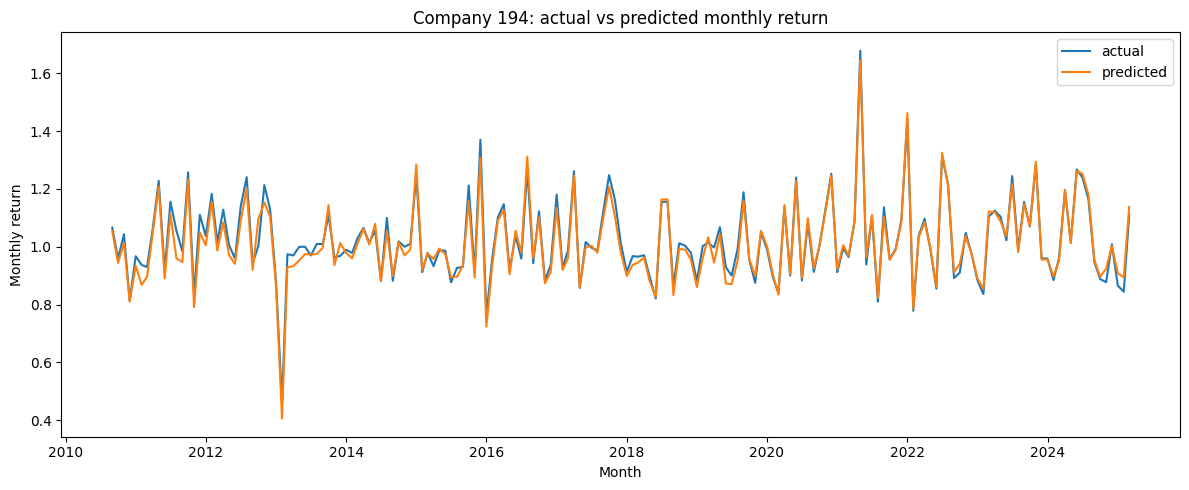

In [52]:
# Holdout inference (CatBoost + CNN)
import matplotlib.pyplot as plt

holdout_panel = holdout_panel.copy()
holdout_inference_inputs = holdout_inference_inputs.copy()

holdout_panel = holdout_panel.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)
holdout_inference_inputs = holdout_inference_inputs.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)

holdout_panel["row_id"] = holdout_panel.index
holdout_inference_inputs["row_id"] = holdout_panel["row_id"]

holdout_features = make_feature_frame(holdout_inference_inputs)
holdout_panel["cb_pred"] = cb_model.predict(holdout_features)

def encode_holdout_for_cnn(
    df: pd.DataFrame,
    columns: list[str],
    categorical_columns: list[str],
    category_maps: dict,
 ) -> pd.DataFrame:
    encoded = pd.DataFrame(index=df.index)
    for column in columns:
        series = df[column] if column in df.columns else pd.Series(np.nan, index=df.index)
        if column in categorical_columns:
            categories = pd.Index(category_maps.get(column, []))
            series = series.astype("string").fillna("__MISSING__")
            if len(categories) > 0:
                series = series.where(series.isin(categories), "__MISSING__")
                encoded[column] = pd.Categorical(series, categories=categories).codes.astype("float32")
            else:
                encoded[column] = pd.Series(np.nan, index=df.index, dtype="float32")
        else:
            encoded[column] = pd.to_numeric(series, errors="coerce").astype("float32")
    return encoded

holdout_cnn_base = encode_holdout_for_cnn(
    holdout_inference_inputs,
    feature_columns,
    cat_features,
    cnn_category_maps,
 )
holdout_cnn_feature_frame = holdout_cnn_base.copy()
holdout_cnn_feature_frame["cb_pred"] = holdout_panel["cb_pred"].astype("float32")
holdout_cnn_feature_frame = holdout_cnn_feature_frame.reindex(columns=cnn_feature_columns)

def build_holdout_sequences(
    panel_df: pd.DataFrame,
    feature_df: pd.DataFrame,
    seq_len: int,
 ):
    sequences = []
    row_ids = []
    ordered = panel_df.sort_values([ID_COLUMN, DATE_COLUMN, "row_id"], kind="mergesort")
    for _, group in ordered.groupby(ID_COLUMN, sort=False):
        group_row_ids = group["row_id"].to_numpy()
        group_features = feature_df.loc[group_row_ids, cnn_feature_columns].to_numpy(dtype=np.float32)
        for end in range(seq_len - 1, len(group)):
            window = group_features[end - seq_len + 1 : end + 1]
            sequences.append(normalize_window(window).T)
            row_ids.append(int(group_row_ids[end]))
    if not sequences:
        empty = np.empty((0, len(cnn_feature_columns), seq_len), dtype=np.float32)
        return empty, np.asarray([], dtype=np.int64)
    return np.stack(sequences).astype(np.float32), np.asarray(row_ids, dtype=np.int64)

X_holdout_cnn, row_id_holdout = build_holdout_sequences(
    holdout_panel,
    holdout_cnn_feature_frame,
    SEQ_LEN,
 )

holdout_panel["cnn_resid_pred"] = np.nan
if len(row_id_holdout) > 0:
    holdout_panel.loc[row_id_holdout, "cnn_resid_pred"] = batched_predict(cnn_model, X_holdout_cnn)

holdout_panel["final_pred"] = holdout_panel["cb_pred"] + holdout_panel["cnn_resid_pred"].fillna(0.0)

holdout_inference = holdout_panel[[
    ID_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
    "cb_pred",
    "cnn_resid_pred",
    "final_pred",
 ]].copy()
holdout_inference = holdout_inference.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)

display(holdout_inference.head())

plot_frame = holdout_inference.dropna(subset=[DATE_COLUMN])
plot_frame = plot_frame.sort_values(DATE_COLUMN)

plt.figure(figsize=(12, 5))
plt.plot(plot_frame[DATE_COLUMN], plot_frame[TARGET_COLUMN], label="actual")
plt.plot(plot_frame[DATE_COLUMN], plot_frame["final_pred"], label="predicted")
plt.title("Company 194: actual vs predicted monthly return")
plt.xlabel("Month")
plt.ylabel("Monthly return")
plt.legend()
plt.tight_layout()

Overall test metrics:


,rows,RMSE,MAE,R2,Directional_Accuracy
0,57570,0.057747,0.032042,0.883385,0.999983


,co_code,months,rmse,mae,r2
0,765,1.0,0.000715,0.000715,NaN
1,1761,1.0,0.001208,0.001208,NaN
2,3550,1.0,0.001660,0.001660,NaN
3,4333,1.0,0.001702,0.001702,NaN
4,2376,1.0,0.002672,0.002672,NaN
5,3531,1.0,0.003155,0.003155,NaN
6,3585,1.0,0.003860,0.003860,NaN
7,1844,1.0,0.003949,0.003949,NaN
8,2334,1.0,0.004359,0.004359,NaN
9,318,1.0,0.004740,0.004740,NaN


KeyboardInterrupt: 

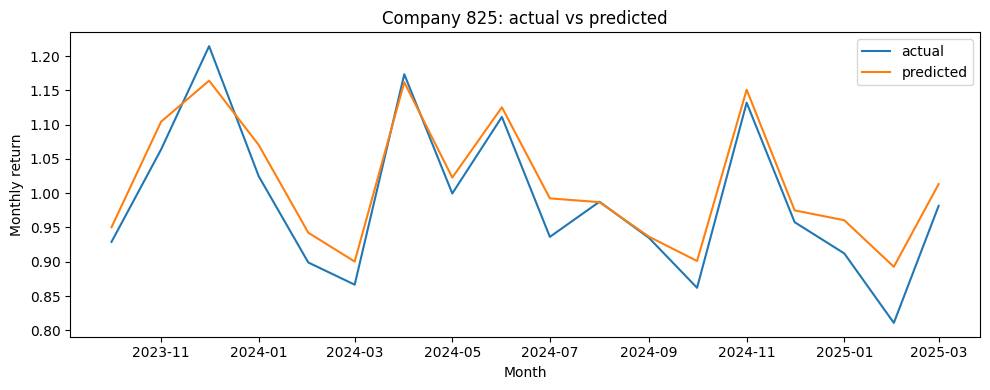

In [53]:
# Test split inference + company-wise plots
import matplotlib.pyplot as plt

TEST_PATH = DATA_DIR / "test.csv"
TEST_TARGETS_PATH = DATA_DIR / "test_targets.csv"
TEST_RESULTS_DIR = Path("testing results company wise")
TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

test_infer = pd.read_csv(TEST_PATH, low_memory=False)
test_infer = coerce_panel_types(test_infer)
test_infer = test_infer.sort_values([ID_COLUMN, DATE_COLUMN], kind="mergesort").reset_index(drop=True)
test_infer["row_id"] = np.arange(len(test_infer))

test_features = make_feature_frame(test_infer)
test_infer["cb_pred"] = cb_model.predict(test_features)

def encode_test_for_cnn(
    df: pd.DataFrame,
    columns: list[str],
    categorical_columns: list[str],
    category_maps: dict,
 ) -> pd.DataFrame:
    encoded = pd.DataFrame(index=df.index)
    for column in columns:
        series = df[column] if column in df.columns else pd.Series(np.nan, index=df.index)
        if column in categorical_columns:
            categories = pd.Index(category_maps.get(column, []))
            series = series.astype("string").fillna("__MISSING__")
            if len(categories) > 0:
                series = series.where(series.isin(categories), "__MISSING__")
                encoded[column] = pd.Categorical(series, categories=categories).codes.astype("float32")
            else:
                encoded[column] = pd.Series(np.nan, index=df.index, dtype="float32")
        else:
            encoded[column] = pd.to_numeric(series, errors="coerce").astype("float32")
    return encoded

test_cnn_base = encode_test_for_cnn(test_infer, feature_columns, cat_features, cnn_category_maps)
test_cnn_feature_frame = test_cnn_base.copy()
test_cnn_feature_frame["cb_pred"] = test_infer["cb_pred"].astype("float32")
test_cnn_feature_frame = test_cnn_feature_frame.reindex(columns=cnn_feature_columns)

def build_test_sequences(
    panel_df: pd.DataFrame,
    feature_df: pd.DataFrame,
    seq_len: int,
 ):
    sequences = []
    row_ids = []
    ordered = panel_df.sort_values([ID_COLUMN, DATE_COLUMN, "row_id"], kind="mergesort")
    for _, group in ordered.groupby(ID_COLUMN, sort=False):
        group_row_ids = group["row_id"].to_numpy()
        group_features = feature_df.loc[group_row_ids, cnn_feature_columns].to_numpy(dtype=np.float32)
        for end in range(seq_len - 1, len(group)):
            window = group_features[end - seq_len + 1 : end + 1]
            sequences.append(normalize_window(window).T)
            row_ids.append(int(group_row_ids[end]))
    if not sequences:
        empty = np.empty((0, len(cnn_feature_columns), seq_len), dtype=np.float32)
        return empty, np.asarray([], dtype=np.int64)
    return np.stack(sequences).astype(np.float32), np.asarray(row_ids, dtype=np.int64)

X_test_cnn, row_id_test = build_test_sequences(
    test_infer,
    test_cnn_feature_frame,
    SEQ_LEN,
 )

test_infer["cnn_resid_pred"] = np.nan
if len(row_id_test) > 0:
    test_infer.loc[row_id_test, "cnn_resid_pred"] = batched_predict(cnn_model, X_test_cnn)

test_infer["final_pred"] = test_infer["cb_pred"] + test_infer["cnn_resid_pred"].fillna(0.0)

if not TEST_TARGETS_PATH.exists():
    print(f"Missing {TEST_TARGETS_PATH}. Skipping evaluation and plots.")
else:
    test_targets = pd.read_csv(TEST_TARGETS_PATH, low_memory=False)
    test_targets = coerce_panel_types(test_targets)
    test_targets = test_targets[[ID_COLUMN, DATE_COLUMN, TARGET_COLUMN]].rename(
        columns={TARGET_COLUMN: "actual_return"}
    )
    eval_frame = test_infer.merge(
        test_targets,
        on=[ID_COLUMN, DATE_COLUMN],
        how="left",
    )
    eval_frame["error"] = eval_frame["actual_return"] - eval_frame["final_pred"]

    valid = eval_frame[["actual_return", "final_pred"]].dropna()
    if valid.empty:
        print("No valid rows to evaluate after merging test targets.")
    else:
        residual = valid["actual_return"] - valid["final_pred"]
        overall_rmse = float(np.sqrt(np.mean(residual ** 2)))
        overall_mae = float(np.mean(np.abs(residual)))
        sst = float(np.sum((valid["actual_return"] - valid["actual_return"].mean()) ** 2))
        overall_r2 = float(1.0 - np.sum(residual ** 2) / sst) if sst > 0 else np.nan
        overall_da = float(np.mean(np.sign(valid["actual_return"]) == np.sign(valid["final_pred"])))
        overall_metrics = pd.DataFrame(
            [
                {
                    "rows": int(len(valid)),
                    "RMSE": overall_rmse,
                    "MAE": overall_mae,
                    "R2": overall_r2,
                    "Directional_Accuracy": overall_da,
                }
            ]
        )
        print("Overall test metrics:")
        display(overall_metrics)

        def per_company_metrics(group: pd.DataFrame) -> pd.Series:
            valid_group = group[["actual_return", "final_pred"]].dropna()
            if valid_group.empty:
                return pd.Series({"months": 0, "rmse": np.nan, "mae": np.nan, "r2": np.nan})
            residuals = valid_group["actual_return"] - valid_group["final_pred"]
            rmse = float(np.sqrt(np.mean(residuals ** 2)))
            mae = float(np.mean(np.abs(residuals)))
            sst = float(np.sum((valid_group["actual_return"] - valid_group["actual_return"].mean()) ** 2))
            r2 = float(1.0 - np.sum(residuals ** 2) / sst) if sst > 0 else np.nan
            return pd.Series({"months": int(len(valid_group)), "rmse": rmse, "mae": mae, "r2": r2})

        company_metrics = (
            eval_frame.groupby(ID_COLUMN, sort=False)
            .apply(per_company_metrics)
            .reset_index()
            .sort_values("rmse")
            .reset_index(drop=True)
        )
        display(company_metrics.head(10))
        company_metrics.to_csv(TEST_RESULTS_DIR / "company_metrics.csv", index=False)

        predictions_out = eval_frame[[
            ID_COLUMN,
            DATE_COLUMN,
            "actual_return",
            "cb_pred",
            "cnn_resid_pred",
            "final_pred",
            "error",
        ]].copy()
        predictions_out.to_csv(TEST_RESULTS_DIR / "test_predictions.csv", index=False)

        plot_rows = eval_frame.dropna(subset=["actual_return", DATE_COLUMN, "final_pred"])
        saved = 0
        for company_id, group in plot_rows.groupby(ID_COLUMN, sort=False):
            group = group.sort_values(DATE_COLUMN)
            plt.figure(figsize=(10, 4))
            plt.plot(group[DATE_COLUMN], group["actual_return"], label="actual")
            plt.plot(group[DATE_COLUMN], group["final_pred"], label="predicted")
            plt.title(f"Company {company_id}: actual vs predicted")
            plt.xlabel("Month")
            plt.ylabel("Monthly return")
            plt.legend()
            plt.tight_layout()
            safe_id = "unknown" if pd.isna(company_id) else str(company_id)
            safe_id = safe_id.replace("/", "_")
            plt.savefig(TEST_RESULTS_DIR / f"company_{safe_id}.png", dpi=150)
            plt.close()
            saved += 1
        print(f"Saved {saved} company plots to {TEST_RESULTS_DIR}")

## Test Evaluation (CatBoost vs CNN)

,rows,RMSE,MAE,Median_AE,MAPE,R2,Bias,Directional_Accuracy,model
0,57570,0.056581,0.031497,0.021593,0.032116,0.888047,-0.015703,0.999983,catboost_only
1,39916,1.015278,1.002582,0.985287,1.000829,-37.565041,1.002582,0.496518,cnn_only
2,57570,0.057747,0.032042,0.021466,0.032635,0.883385,-0.015511,0.999983,catboost_plus_cnn


Saved metrics to testing results company wise/test_metrics_summary.csv


[0409/142458.765537:ERROR:third_party/crashpad/crashpad/util/file/file_io_posix.cc:153] open /home/mushu/.config/BraveSoftware/Brave-Browser/Crash Reports/pending/7b2febe9-2942-467a-bb18-e67e04a13edc.lock: File exists (17)


Opening in existing browser session.


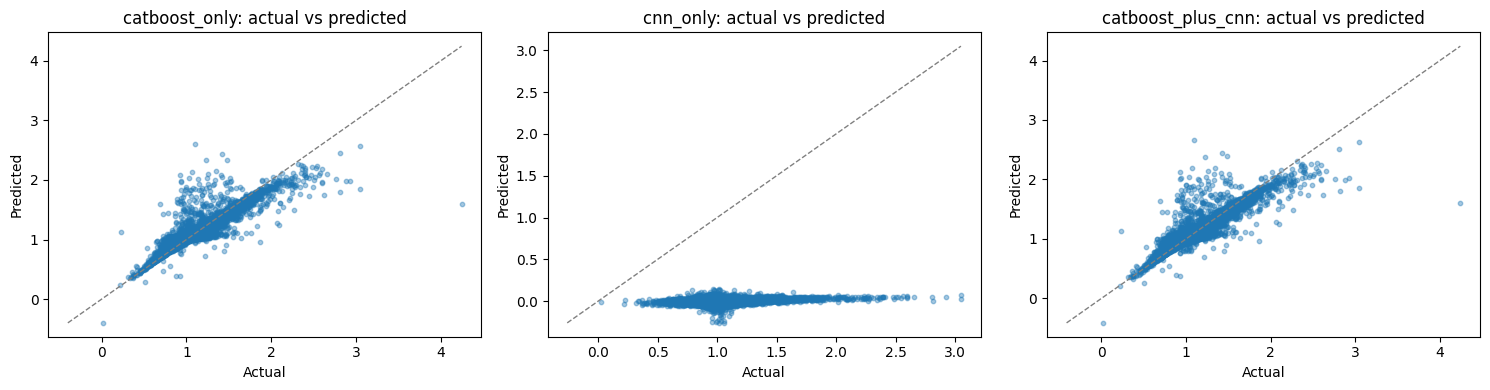

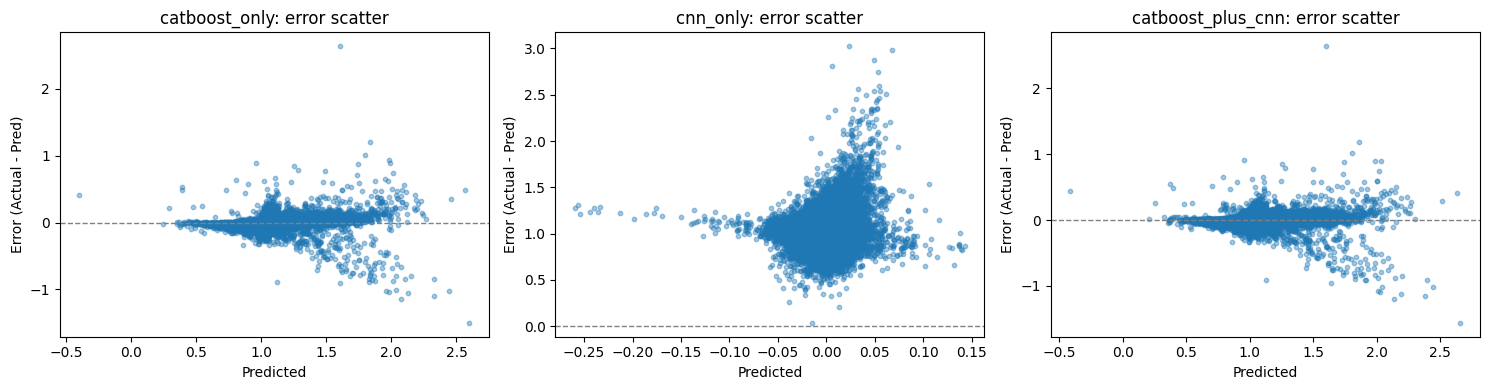

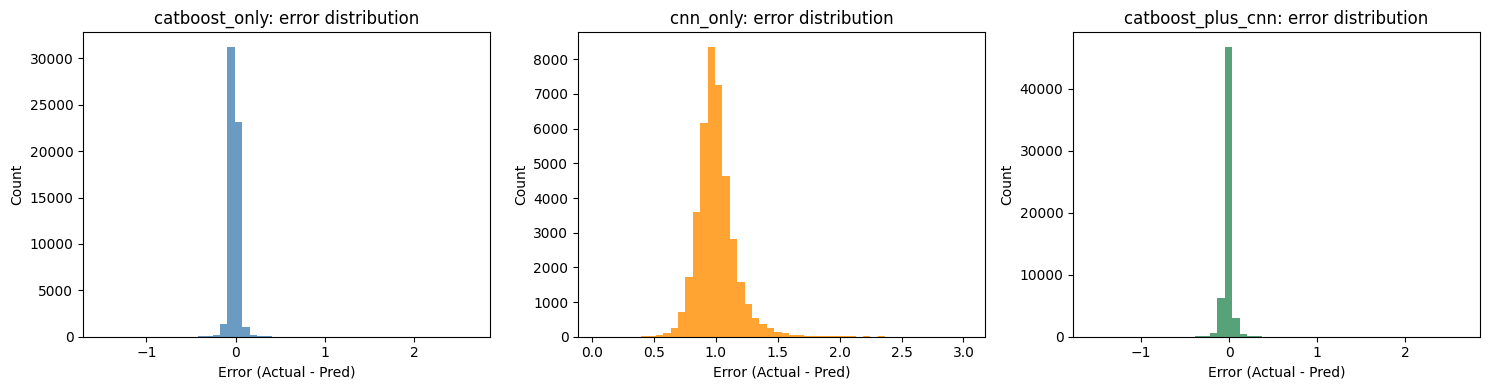

In [58]:
# Test-only evaluation + error plots (CatBoost / CNN / Combined)
import matplotlib.pyplot as plt

TEST_RESULTS_DIR = Path("testing results company wise")
preds_path = TEST_RESULTS_DIR / "test_predictions.csv"
targets_path = DATA_DIR / "test_targets.csv"
metrics_out_path = TEST_RESULTS_DIR / "test_metrics_summary.csv"

def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").dropna()

if not preds_path.exists():
    print(f"Missing {preds_path}. Run the test inference cell first.")
else:
    preds_df = pd.read_csv(preds_path, low_memory=False)

    if "actual_return" not in preds_df.columns:
        if targets_path.exists():
            targets = pd.read_csv(targets_path, low_memory=False)
            targets = coerce_panel_types(targets)
            targets = targets[[ID_COLUMN, DATE_COLUMN, TARGET_COLUMN]].rename(
                columns={TARGET_COLUMN: "actual_return"}
            )
            preds_df = preds_df.merge(targets, on=[ID_COLUMN, DATE_COLUMN], how="left")
        elif TARGET_COLUMN in preds_df.columns:
            preds_df = preds_df.rename(columns={TARGET_COLUMN: "actual_return"})
        else:
            print("Missing actual return values; cannot compute metrics.")
            preds_df["actual_return"] = np.nan

    if ("final_pred" not in preds_df.columns
        and "cb_pred" in preds_df.columns
        and "cnn_resid_pred" in preds_df.columns):
        preds_df["final_pred"] = preds_df["cb_pred"] + preds_df["cnn_resid_pred"].fillna(0.0)

    # CNN predicts residuals; cnn_only uses residual outputs directly for comparison.
    model_cols = {
        "catboost_only": "cb_pred",
        "cnn_only": "cnn_resid_pred",
        "catboost_plus_cnn": "final_pred",
    }

    def compute_metrics(df: pd.DataFrame, pred_col: str) -> dict:
        valid = df[["actual_return", pred_col]].dropna()
        if valid.empty:
            return {
                "rows": 0,
                "RMSE": np.nan,
                "MAE": np.nan,
                "Median_AE": np.nan,
                "MAPE": np.nan,
                "R2": np.nan,
                "Bias": np.nan,
                "Directional_Accuracy": np.nan,
            }
        y_true = valid["actual_return"].to_numpy(dtype=float)
        y_pred = valid[pred_col].to_numpy(dtype=float)
        error = y_true - y_pred
        rmse = float(np.sqrt(np.mean(error ** 2)))
        mae = float(np.mean(np.abs(error)))
        median_ae = float(np.median(np.abs(error)))
        sst = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = float(1.0 - np.sum(error ** 2) / sst) if sst > 0 else np.nan
        denom = np.abs(y_true)
        mape_mask = denom > 1e-8
        mape = float(np.mean(np.abs(error[mape_mask]) / denom[mape_mask])) if np.any(mape_mask) else np.nan
        bias = float(np.mean(error))
        directional_accuracy = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
        return {
            "rows": int(len(valid)),
            "RMSE": rmse,
            "MAE": mae,
            "Median_AE": median_ae,
            "MAPE": mape,
            "R2": r2,
            "Bias": bias,
            "Directional_Accuracy": directional_accuracy,
        }

    metrics_rows = []
    for name, col in model_cols.items():
        if col not in preds_df.columns:
            print(f"Missing {col}; skipping {name}.")
            continue
        row = compute_metrics(preds_df, col)
        row["model"] = name
        metrics_rows.append(row)

    metrics_df = pd.DataFrame(metrics_rows)
    display(metrics_df)
    metrics_df.to_csv(metrics_out_path, index=False)
    print(f"Saved metrics to {metrics_out_path}")

    for name, col in model_cols.items():
        if col in preds_df.columns:
            preds_df[f"error_{name}"] = preds_df["actual_return"] - preds_df[col]

    # Scatter: actual vs predicted
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, col) in zip(axes, model_cols.items()):
        if col not in preds_df.columns:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name}")
            continue
        valid = preds_df[["actual_return", col]].dropna()
        if valid.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name}")
            continue
        ax.scatter(valid["actual_return"], valid[col], s=10, alpha=0.4)
        min_val = float(min(valid["actual_return"].min(), valid[col].min()))
        max_val = float(max(valid["actual_return"].max(), valid[col].max()))
        ax.plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"{name}: actual vs predicted")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
    plt.tight_layout()

    # Scatter: error vs predicted
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, col) in zip(axes, model_cols.items()):
        err_col = f"error_{name}"
        if err_col not in preds_df.columns or col not in preds_df.columns:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name}")
            continue
        valid = preds_df[[col, err_col]].dropna()
        if valid.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name}")
            continue
        ax.scatter(valid[col], valid[err_col], s=10, alpha=0.4)
        ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"{name}: error scatter")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Error (Actual - Pred)")
    plt.tight_layout()

    # Error distribution per model
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = {
        "catboost_only": "steelblue",
        "cnn_only": "darkorange",
        "catboost_plus_cnn": "seagreen",
    }
    for ax, (name, col) in zip(axes, model_cols.items()):
        err_col = f"error_{name}"
        series = preds_df[err_col].dropna() if err_col in preds_df.columns else pd.Series([], dtype="float64")
        if series.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name}")
            continue
        ax.hist(series, bins=50, color=colors.get(name, "gray"), alpha=0.8)
        ax.set_title(f"{name}: error distribution")
        ax.set_xlabel("Error (Actual - Pred)")
        ax.set_ylabel("Count")
    plt.tight_layout()

    # Row-wise plot: actual vs predictions (sorted by date/company), interactive
    row_plot = preds_df.dropna(subset=["actual_return"]).copy()
    if row_plot.empty:
        print("No rows with actual_return for row-wise plot.")
    else:
        if DATE_COLUMN in row_plot.columns and ID_COLUMN in row_plot.columns:
            row_plot = row_plot.sort_values([DATE_COLUMN, ID_COLUMN], kind="mergesort")
            x_label = "Row (sorted by date/company)"
        else:
            row_plot = row_plot.reset_index(drop=True)
            x_label = "Row"
        x_vals = np.arange(len(row_plot))
        try:
            import plotly.graph_objects as go
        except Exception as exc:
            print(f"Plotly not available ({exc}). Run: %pip install plotly")
        else:
            fig = go.Figure()
            fig.add_trace(
                go.Scatter(
                    x=x_vals,
                    y=row_plot["actual_return"],
                    mode="lines",
                    name="actual",
                )
            )
            for name, col in model_cols.items():
                if col in row_plot.columns:
                    fig.add_trace(
                        go.Scatter(
                            x=x_vals,
                            y=row_plot[col],
                            mode="lines",
                            name=name,
                            opacity=0.7,
                        )
                    )
            fig.update_layout(
                title="Test vs actual (row-wise)",
                xaxis_title=x_label,
                yaxis_title="Monthly return",
                height=400,
            )
            try:
                fig.show()
            except Exception as exc:
                if "nbformat" in str(exc).lower():
                    try:
                        fig.show("browser")
                    except Exception as browser_exc:
                        html_path = TEST_RESULTS_DIR / "rowwise_plot.html"
                        fig.write_html(html_path, include_plotlyjs="cdn")
                        print(f"Saved interactive plot to {html_path}.")
                        print(f"Browser render failed: {browser_exc}")
                else:
                    print(f"Plotly render failed: {exc}")
